## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [2]:
%reload_ext autoreload
%autoreload 2


In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage, plot_uv_coverage_2


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


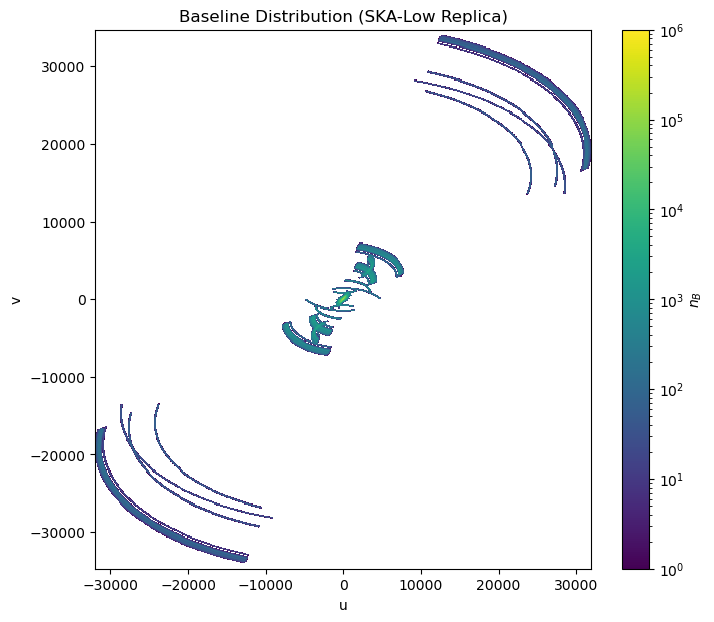

In [95]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/ska_low_AA2.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T01:00:00",
    "utc_end": "2023-11-21T06:00:00",
    "step_min": 0.5,
    "n_freqs": 150,
    'bandwidth': 1e06, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 10,
    "max_offset_deg": 1.0, 
    "flux_range": [0.1, 2,0],
    # "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ , times_sec = visibilities_simulation(SKA_LOW_AA1)

# plot_uv_coverage(uvw, unit='km')
plot_uv_coverage_2(uvw, 512)

In [44]:
print("uvw shape: ", uvw.shape)
print("V shape: ", V.shape)
print("V baselines shape: ", V[0].shape)
# print("Primeros 3 registros del baseline 0: \n", V[0][:3])   

uvw shape:  (2016, 601, 3)
V shape:  (2016, 601, 100)
V baselines shape:  (601, 100)


Inyección de RFI

In [96]:
from modules.noise import narrowband_rfi

V_rfi, k, f_rfi = narrowband_rfi(
    V,
    frequencies,
    amplitude=10,
    k_rfi=[10, 40, 75],
    seed=42
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted = V + V_rfi

Canal RFI: [10 40 75]
Frecuencia [MHz]: [135.5 165.5 200.5]


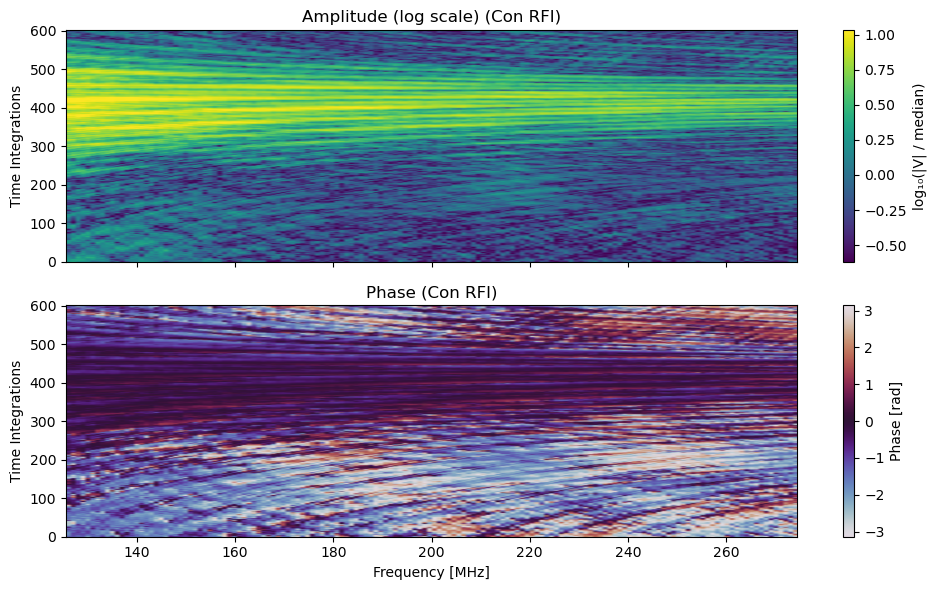

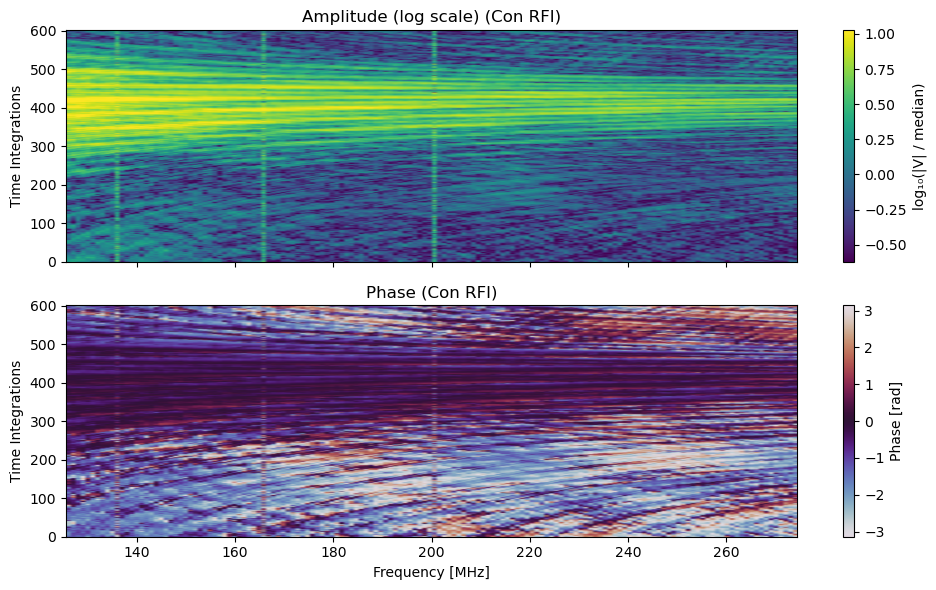

In [97]:
from modules.plots import plot_time_frequency

plot_time_frequency(
    V,
    frequencies,
    title_suffix="(Con RFI)"
)

plot_time_frequency(
    V_corrupted,
    frequencies,
    title_suffix="(Con RFI)"
)

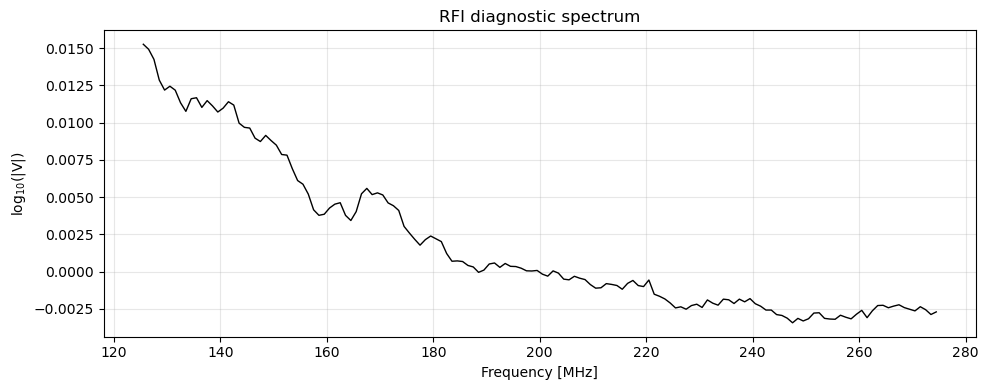

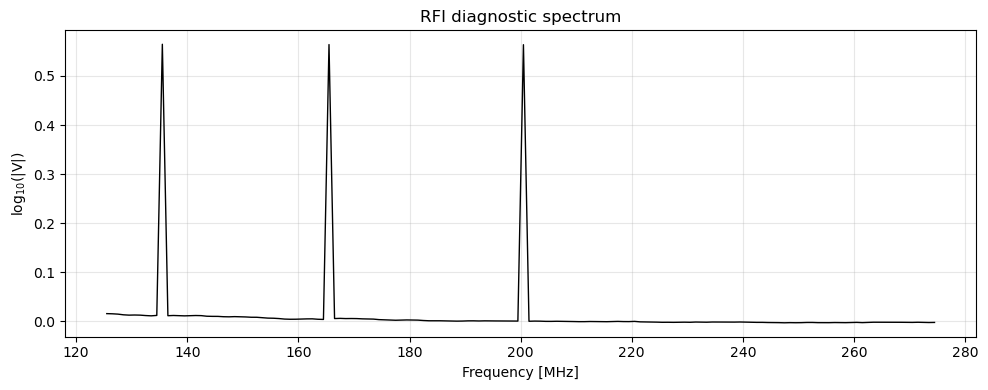

In [98]:
from modules.plots import plot_rfi_spectrum

plot_rfi_spectrum(
    V,
    frequencies,
    log_mode="log10",
    normalize=True,
    title="RFI diagnostic spectrum"
)

plot_rfi_spectrum(
    V_corrupted,
    frequencies,
    log_mode="log10",
    normalize=True,
    title="RFI diagnostic spectrum"
)


In [99]:
from modules.noise import broadband_rfi

V_rfi_bb, k_bb, f_rfi_bb = broadband_rfi(
    V,
    frequencies,
    amplitude=5,
    k_range=(10,15),
    seed=42
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted_bb = V + V_rfi_bb

Canal RFI: [10 40 75]
Frecuencia [MHz]: [135.5 165.5 200.5]


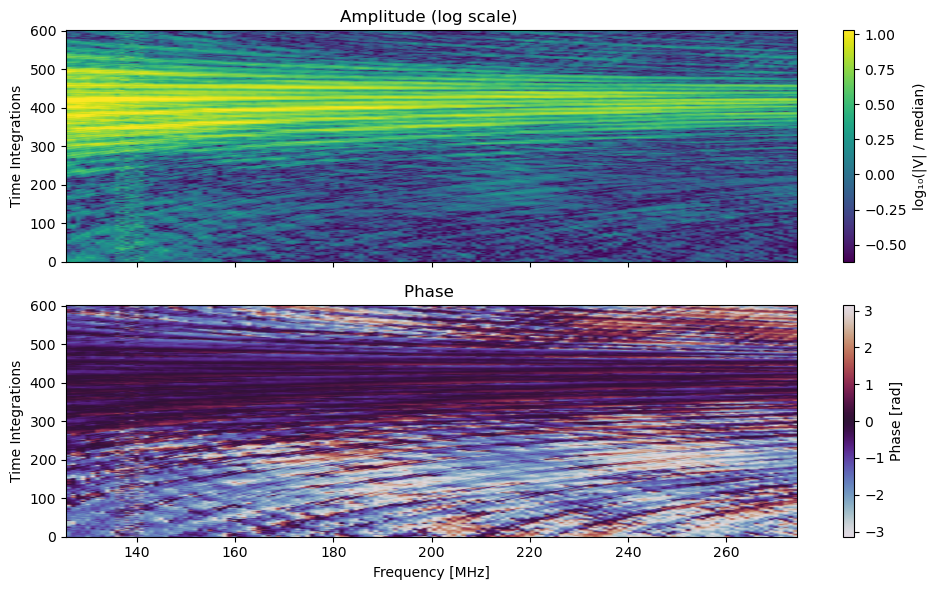

In [100]:
plot_time_frequency(V_corrupted_bb, frequencies)

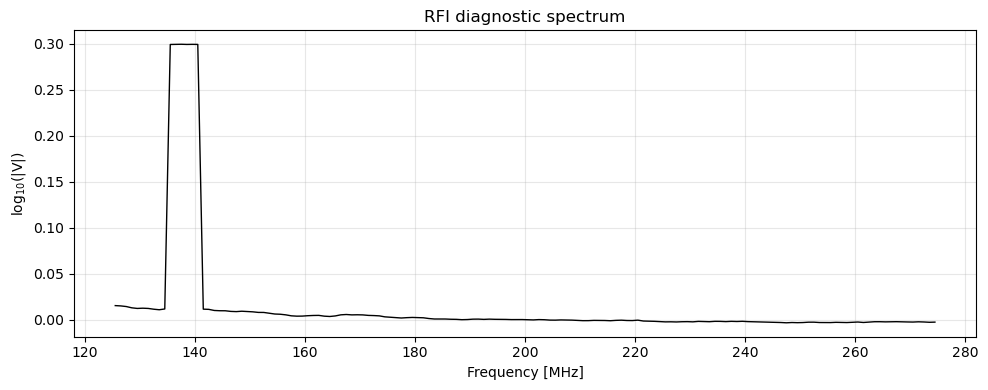

In [101]:
plot_rfi_spectrum(
    V_corrupted_bb,
    frequencies,
    log_mode="log10",
    normalize=True,
    title="RFI diagnostic spectrum"
)

In [152]:
from modules.noise import transient_rfi


V_rfi_t, k_t = transient_rfi(
    V,
    times=times_sec,
    amplitude=500,
    duration_steps=1,
    t_rfi=3600,
    seed=42
)

V_corrupted_t = V + V_rfi_t

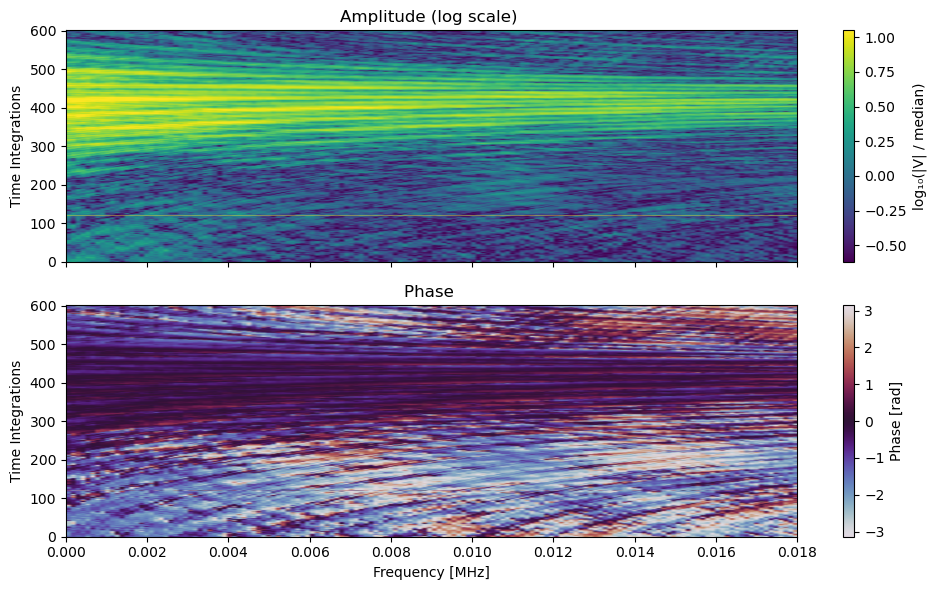

In [153]:
plot_time_frequency(V_corrupted_t, times_sec)

In [156]:
uvw_lambda.shape

(2016, 601, 150, 3)

In [ ]:
from modules.noise import correlated_rfi

V_rfi_corr, C_mask = correlated_rfi(
    V,
    uvw_lambda=uvw_lambda, 
    amplitude=20.0,
    correlation_length=100.0,
    phase_mode='random'

)

V_total = V + V_rfi_corr

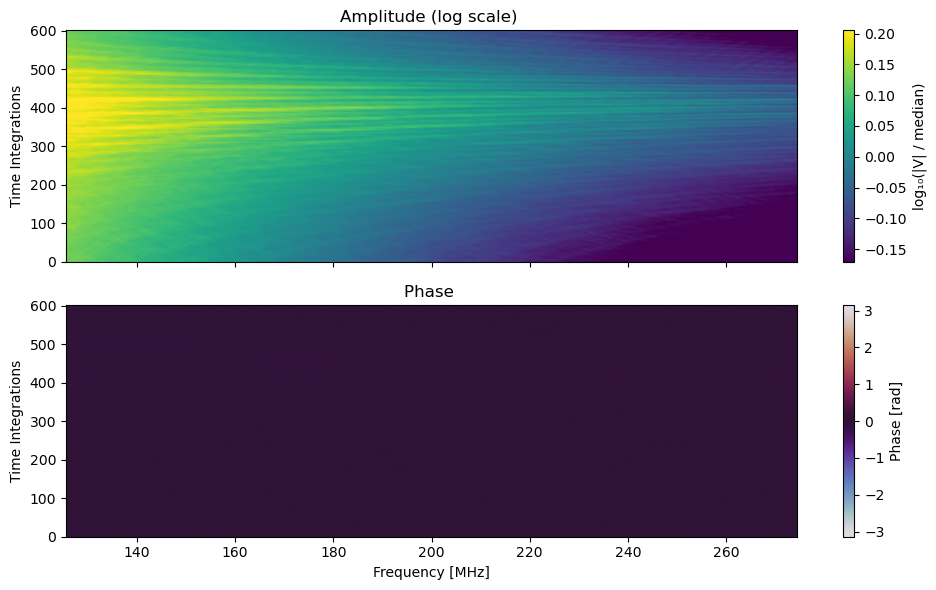

In [162]:
plot_time_frequency(V_total, frequencies)